In [174]:
import pandas as pd 
import numpy as np

from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def format_symbol(code):
    """
    Format stock symbol with proper prefix based on code
    """
    if code.startswith('6'):
        return f'sh{code}'
    elif code.startswith('9') or code.startswith('4'):
        return f'bj{code}'
    else:
        return f'sz{code}'

In [3]:
q4_stocks = pd.read_csv('../data/output/aligned_stock_code_pool.csv', dtype=str)
# change colunm name 
q4_stocks = q4_stocks.rename(columns={"Unnamed: 0": "stock_codes"})
q4_stocks

,stock_codes,201101,201102,201103,201104,201105,201106,201107,201108,201109,...,202506,202507,202508,202509,202510,202511,202512,202601,stock_counts,name
0,000001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31.0,平安银行
1,000002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,26.0,万 科Ａ
2,000039,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,中集集团
3,000090,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.0,天健集团
4,000100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,TCL科技
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150,603766,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,隆鑫通用
151,605368,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,蓝天燃气
152,605377,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,华旺科技
153,688606,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,奥泰生物


In [8]:
mask = q4_stocks.drop(columns=['stock_counts', 'name']).notna()
rightmost_col_idx = mask.iloc[:, ::-1].idxmax(axis=1)
rightmost_col_idx

0      201502
1      202105
2      202111
3      202311
4      201412
        ...  
150    201708
151    202305
152    202411
153    202302
154    202601
Length: 155, dtype: object

In [11]:
stock_last_seen = pd.concat([q4_stocks['stock_codes'], rightmost_col_idx], axis=1)
stock_last_seen = stock_last_seen.rename(columns={0: 'last_seen'})
# apply the format symbol function to the stock codes
stock_last_seen['stock_symbols'] = stock_last_seen['stock_codes'].apply(format_symbol)
# remove the last row
stock_last_seen = stock_last_seen.iloc[:-1, :]
stock_last_seen

,stock_codes,last_seen,stock_symbols
0,000001,201502,sz000001
1,000002,202105,sz000002
2,000039,202111,sz000039
3,000090,202311,sz000090
4,000100,201412,sz000100
...,...,...,...
149,603077,202305,sh603077
150,603766,201708,sh603766
151,605368,202305,sh605368
152,605377,202411,sh605377


### from last seen to max point

In [12]:
stock_trends = {}

symbols = stock_last_seen['stock_symbols'].tolist()

for i, symbol in tqdm(enumerate(symbols)):
    
    last_seen_year = int(stock_last_seen['last_seen'][i][:4])
    last_seen_month = int(stock_last_seen['last_seen'][i][4:6])
    # print(symbol, last_seen_year, last_seen_month)

    # load the price data
    price_df = pd.read_csv(f"../data/input/price-data/20260124/price_data_{symbol}_20260124.csv")
    price_df['report_date'] = pd.to_datetime(price_df['report_date'])
    price_df['year'] = price_df['report_date'].dt.year
    price_df['month'] = price_df['report_date'].dt.month

    # find the last seen row 
    last_seen_row = price_df.query(f"year == {last_seen_year} and month == {last_seen_month}")
    last_seen_row_date = last_seen_row.iloc[-1]['report_date']
    last_seen_row_price = last_seen_row.iloc[-1]['close']
    # print(last_seen_row_price, last_seen_row_date)

    # find the row with the max close price
    max_close_price_row = price_df.loc[price_df.query(f"year >= {last_seen_year} and month >= {last_seen_month}")['close'].idxmax()]
    max_close_price = max_close_price_row['close']
    max_close_price_date = max_close_price_row['report_date']
    max_close_price_year = max_close_price_date.year
    max_close_price_month = max_close_price_date.month

    # print(max_close_price, max_close_price_date, max_close_price_year, max_close_price_month)
    stock_trends[symbol] = [last_seen_row_date, last_seen_year, last_seen_month, last_seen_row_price, 
                            max_close_price_date, max_close_price_year, max_close_price_month, max_close_price]
stock_trends_df = pd.DataFrame.from_dict(stock_trends, orient='index', columns=[
    'last_seen_date', 'last_seen_year', 'last_seen_month', 'last_seen_price',
    'max_close_date', 'max_close_year', 'max_close_month', 'max_close_price'
])
stock_trends_df

154it [00:00, 176.70it/s]


,last_seen_date,last_seen_year,last_seen_month,last_seen_price,max_close_date,max_close_year,max_close_month,max_close_price
sz000001,2015-02-27,2015,2,13.99,2021-05-26,2021,5,25.01
sz000002,2021-05-31,2021,5,26.70,2021-05-07,2021,5,28.00
sz000039,2021-11-30,2021,11,17.03,2021-12-03,2021,12,17.41
sz000090,2023-11-30,2023,11,5.07,2023-11-14,2023,11,5.54
sz000100,2014-12-31,2014,12,3.80,2020-12-02,2020,12,8.01
...,...,...,...,...,...,...,...,...
sh603077,2023-05-31,2023,5,2.35,2023-05-04,2023,5,2.70
sh603766,2017-08-31,2017,8,7.70,2025-12-17,2025,12,16.29
sh605368,2023-05-31,2023,5,9.37,2024-08-22,2024,8,14.50
sh605377,2024-11-29,2024,11,12.64,2024-12-12,2024,12,13.86


In [13]:
stock_trends_recent = stock_trends_df.query("last_seen_year < 2025").copy()
stock_trends_recent['price_change'] = stock_trends_recent['max_close_price'] - stock_trends_recent['last_seen_price']
stock_trends_recent['price_change_pct'] = stock_trends_recent['price_change'] / stock_trends_recent['last_seen_price'] * 100
stock_trends_recent['date gap'] = (stock_trends_recent['max_close_date'] - stock_trends_recent['last_seen_date']).dt.days

stock_trends_recent

,last_seen_date,last_seen_year,last_seen_month,last_seen_price,max_close_date,max_close_year,max_close_month,max_close_price,price_change,price_change_pct,date gap
sz000001,2015-02-27,2015,2,13.99,2021-05-26,2021,5,25.01,11.02,78.770550,2280
sz000002,2021-05-31,2021,5,26.70,2021-05-07,2021,5,28.00,1.30,4.868914,-24
sz000039,2021-11-30,2021,11,17.03,2021-12-03,2021,12,17.41,0.38,2.231356,3
sz000090,2023-11-30,2023,11,5.07,2023-11-14,2023,11,5.54,0.47,9.270217,-16
sz000100,2014-12-31,2014,12,3.80,2020-12-02,2020,12,8.01,4.21,110.789474,2163
...,...,...,...,...,...,...,...,...,...,...,...
sh603077,2023-05-31,2023,5,2.35,2023-05-04,2023,5,2.70,0.35,14.893617,-27
sh603766,2017-08-31,2017,8,7.70,2025-12-17,2025,12,16.29,8.59,111.558442,3030
sh605368,2023-05-31,2023,5,9.37,2024-08-22,2024,8,14.50,5.13,54.749200,449
sh605377,2024-11-29,2024,11,12.64,2024-12-12,2024,12,13.86,1.22,9.651899,13


(array([59., 28., 13.,  7.,  5.,  3.,  1.,  2.,  1.,  3.]),
 array([  1.33079848,  55.95962339, 110.58844831, 165.21727322,
        219.84609814, 274.47492305, 329.10374796, 383.73257288,
        438.36139779, 492.99022271, 547.61904762]),
 <BarContainer object of 10 artists>)

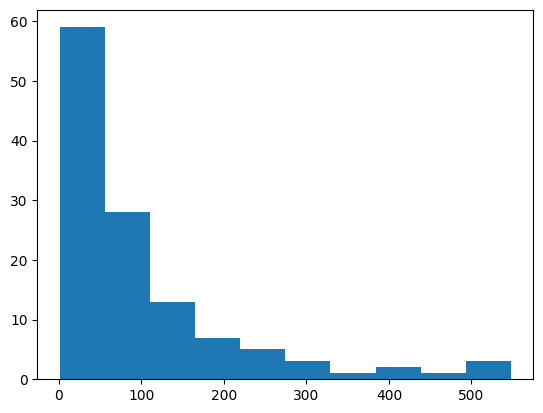

In [14]:
qualified_stocks = stock_trends_recent[stock_trends_recent['last_seen_date'] < stock_trends_recent['max_close_date']]
plt.hist(qualified_stocks['price_change_pct'])

(array([39., 22., 20.,  6.,  9.,  8.,  2.,  7.,  4.,  5.]),
 array([2.0000e+00, 4.0670e+02, 8.1140e+02, 1.2161e+03, 1.6208e+03,
        2.0255e+03, 2.4302e+03, 2.8349e+03, 3.2396e+03, 3.6443e+03,
        4.0490e+03]),
 <BarContainer object of 10 artists>)

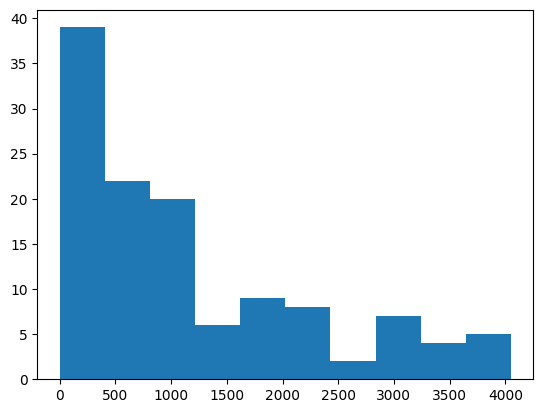

In [15]:
plt.hist(qualified_stocks['date gap'])

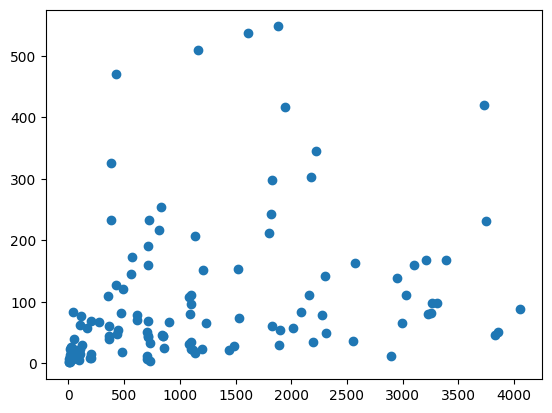

In [16]:
plt.scatter(qualified_stocks['date gap'], qualified_stocks['price_change_pct'])

### from last seen to 1 year later

In [162]:
stock_trends = {}

stock_last_seen_filtered = stock_last_seen[~stock_last_seen.last_seen.str.startswith('2025') & 
                                           ~stock_last_seen.last_seen.str.startswith('2026') ]
stock_last_seen_filtered = stock_last_seen_filtered.reset_index()
symbols = stock_last_seen_filtered['stock_symbols'].tolist()

for i, symbol in tqdm(enumerate(symbols)):
    
    last_seen_year = int(stock_last_seen_filtered['last_seen'][i][:4])
    last_seen_month = int(stock_last_seen_filtered['last_seen'][i][4:6])
    # print(symbol, last_seen_year, last_seen_month)

    # load the price data
    price_df = pd.read_csv(f"../data/input/price-data/20260125/price_data_{symbol}_20260125.csv")
    price_df['report_date'] = pd.to_datetime(price_df['report_date'])
    price_df['year'] = price_df['report_date'].dt.year
    price_df['month'] = price_df['report_date'].dt.month

    # find the last seen row 
    last_seen_row = price_df.query(f"year == {last_seen_year} and month == {last_seen_month}")
    last_seen_row_date = last_seen_row.iloc[-1]['report_date']
    last_seen_row_price = last_seen_row.iloc[-1]['close']
    # print(last_seen_row_price, last_seen_row_date)

    # find the row with the max close price
    # some stocks have no data for the next year the same month
    try:
        sell_close_price_row = price_df.query(f"year == {last_seen_year + 1} and month == {last_seen_month}").iloc[-1, :]
    except Exception:
        sell_close_price_row = price_df.query(f"year == {last_seen_year + 1} and month == {last_seen_month + 1}").iloc[-1, :]
    sell_close_price = sell_close_price_row['close']
    sell_close_price_date = sell_close_price_row['report_date']
    sell_close_price_year = sell_close_price_date.year
    sell_close_price_month = sell_close_price_date.month

    # print(max_close_price, max_close_price_date, max_close_price_year, max_close_price_month)
    stock_trends[symbol] = [last_seen_row_date, last_seen_year, last_seen_month, last_seen_row_price, 
                            sell_close_price_date, sell_close_price_year, sell_close_price_month, sell_close_price]
stock_trends_df = pd.DataFrame.from_dict(stock_trends, orient='index', columns=[
    'last_seen_date', 'last_seen_year', 'last_seen_month', 'last_seen_price',
    'sell_close_date', 'sell_close_year', 'sell_close_month', 'sell_close_price'
])

# calculate the price change
stock_trends_df['price_change'] = stock_trends_df['sell_close_price'] - stock_trends_df['last_seen_price']
stock_trends_df['price_change_pct'] = stock_trends_df['price_change'] / stock_trends_df['last_seen_price'] * 100
stock_trends_df

138it [00:00, 196.27it/s]


,last_seen_date,last_seen_year,last_seen_month,last_seen_price,sell_close_date,sell_close_year,sell_close_month,sell_close_price,price_change,price_change_pct
sz000001,2015-02-27,2015,2,1078.66,2016-02-29,2016,2,892.36,-186.30,-17.271429
sz000002,2021-05-31,2021,5,3824.00,2022-05-31,2022,5,2697.23,-1126.77,-29.465743
sz000039,2021-11-30,2021,11,533.81,2022-11-30,2022,11,367.66,-166.15,-31.125307
sz000090,2023-11-30,2023,11,45.49,2024-11-29,2024,11,42.40,-3.09,-6.792702
sz000100,2014-12-31,2014,12,10.48,2015-12-31,2015,12,11.90,1.42,13.549618
...,...,...,...,...,...,...,...,...,...,...
sh603077,2023-05-31,2023,5,32.90,2024-05-31,2024,5,28.08,-4.82,-14.650456
sh603766,2017-08-31,2017,8,21.02,2018-08-31,2018,8,14.61,-6.41,-30.494767
sh605368,2023-05-31,2023,5,15.19,2024-05-31,2024,5,23.11,7.92,52.139566
sh605377,2024-11-29,2024,11,29.24,2025-11-28,2025,11,25.24,-4.00,-13.679891


count    138.000000
mean      12.778710
std       48.145921
min      -53.127455
25%      -14.196886
50%        0.746929
75%       31.120827
max      296.825397
Name: price_change_pct, dtype: float64


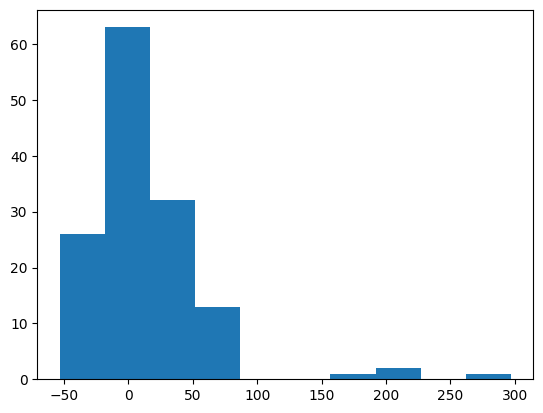

In [163]:
print(stock_trends_df.price_change_pct.describe())
plt.hist(stock_trends_df['price_change_pct'])
plt.show()

### return vs counts

In [164]:
stock_counts = q4_stocks[['stock_codes', 'stock_counts']].copy()
# apply symbol format to stock codes
stock_counts['stock_codes'] = stock_counts['stock_codes'].apply(format_symbol)
stock_counts['stock_counts'] = stock_counts['stock_counts'].astype('float')
stock_counts.head()

,stock_codes,stock_counts
0,sz000001,31.0
1,sz000002,26.0
2,sz000039,3.0
3,sz000090,10.0
4,sz000100,4.0


In [165]:
stock_return = stock_trends_df.reset_index().rename(columns={"index": "stock_codes"})
stock_return = pd.merge(stock_return, stock_counts, on="stock_codes", how='left', validate='1:1')
stock_return

,stock_codes,last_seen_date,last_seen_year,last_seen_month,last_seen_price,sell_close_date,sell_close_year,sell_close_month,sell_close_price,price_change,price_change_pct,stock_counts
0,sz000001,2015-02-27,2015,2,1078.66,2016-02-29,2016,2,892.36,-186.30,-17.271429,31.0
1,sz000002,2021-05-31,2021,5,3824.00,2022-05-31,2022,5,2697.23,-1126.77,-29.465743,26.0
2,sz000039,2021-11-30,2021,11,533.81,2022-11-30,2022,11,367.66,-166.15,-31.125307,3.0
3,sz000090,2023-11-30,2023,11,45.49,2024-11-29,2024,11,42.40,-3.09,-6.792702,10.0
4,sz000100,2014-12-31,2014,12,10.48,2015-12-31,2015,12,11.90,1.42,13.549618,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...
133,sh603077,2023-05-31,2023,5,32.90,2024-05-31,2024,5,28.08,-4.82,-14.650456,4.0
134,sh603766,2017-08-31,2017,8,21.02,2018-08-31,2018,8,14.61,-6.41,-30.494767,3.0
135,sh605368,2023-05-31,2023,5,15.19,2024-05-31,2024,5,23.11,7.92,52.139566,1.0
136,sh605377,2024-11-29,2024,11,29.24,2025-11-28,2025,11,25.24,-4.00,-13.679891,5.0


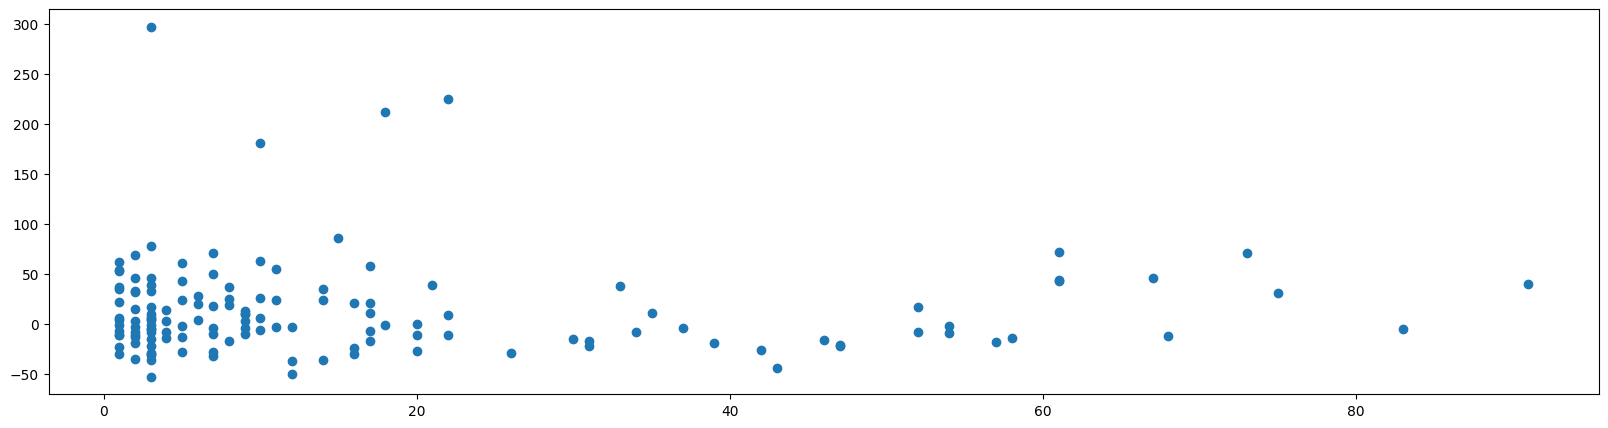

In [166]:
plt.figure(figsize=(20, 5))
plt.scatter(stock_return['stock_counts'], stock_return['price_change_pct'])

### return by year

In [167]:
stock_return.groupby('last_seen_year').agg({"stock_codes": "count", 
                                           "price_change_pct": "mean",})

,stock_codes,price_change_pct
last_seen_year,,
2011,3,-22.167970
2012,4,-16.190168
2013,5,43.191150
2014,7,101.556073
2015,14,-9.816051
2016,15,11.792316
2017,13,1.172828
2018,5,23.079879
2019,5,19.402579


### price change trends after last seen

In [171]:
stock_trends = []

stock_last_seen_filtered = stock_last_seen[~stock_last_seen.last_seen.str.startswith('2025') & 
                                           ~stock_last_seen.last_seen.str.startswith('2026') ]
stock_last_seen_filtered = stock_last_seen_filtered.reset_index()
symbols = stock_last_seen_filtered['stock_symbols'].tolist()

for i, symbol in tqdm(enumerate(symbols)):
    
    last_seen_year = int(stock_last_seen_filtered['last_seen'][i][:4])
    last_seen_month = int(stock_last_seen_filtered['last_seen'][i][4:6])
    # print(symbol, last_seen_year, last_seen_month)

    # load the price data
    price_df = pd.read_csv(f"../data/input/price-data/20260125/price_data_{symbol}_20260125.csv")
    price_df['report_date'] = pd.to_datetime(price_df['report_date'])
    price_df['year'] = price_df['report_date'].dt.year
    price_df['month'] = price_df['report_date'].dt.month

    # find the last seen row 
    last_seen_row = price_df.query(f"year == {last_seen_year} and month == {last_seen_month}")
    last_seen_row_date = last_seen_row.iloc[-1]['report_date']
    last_seen_row_price = last_seen_row.iloc[-1]['close']
    # print(last_seen_row_price, last_seen_row_date)

    # calculate price change after last seen
    price_after_df = price_df.query(f"report_date > '{last_seen_row_date}'").copy()
    price_after_df['price_change_pct'] = (price_after_df['close'] / last_seen_row_price - 1) * 100
    price_after_df['stock_symbol'] = symbol

    stock_trends.append(price_after_df)
stock_trends_df = pd.concat(stock_trends).reset_index()

print(stock_trends_df.shape)
stock_trends_df

138it [00:00, 180.09it/s]

(227046, 10)


,index,report_date,open,high,low,close,year,month,price_change_pct,stock_symbol
0,986,2015-03-02,1081.74,1086.37,1069.40,1081.74,2015,3,0.285539,sz000001
1,987,2015-03-03,1077.89,1077.89,1047.82,1048.59,2015,3,-2.787718,sz000001
2,988,2015-03-04,1050.13,1057.84,1040.88,1046.27,2015,3,-3.002800,sz000001
3,989,2015-03-05,1040.88,1043.19,1024.69,1031.62,2015,3,-4.360966,sz000001
4,990,2015-03-06,1030.85,1041.65,1029.31,1036.25,2015,3,-3.931730,sz000001
...,...,...,...,...,...,...,...,...,...,...
227041,1169,2026-01-19,121.18,122.42,120.48,122.22,2026,1,10.436433,sh688606
227042,1170,2026-01-20,125.94,131.50,125.20,125.39,2026,1,13.300804,sh688606
227043,1171,2026-01-21,127.37,127.57,125.33,127.28,2026,1,15.008584,sh688606
227044,1172,2026-01-22,129.42,132.17,127.44,128.79,2026,1,16.373001,sh688606


In [168]:
stock_return.groupby('last_seen_year').agg({"stock_codes": "count", 
                                           "price_change_pct": "median",})

,stock_codes,price_change_pct
last_seen_year,,
2011,3,-11.559516
2012,4,-14.046832
2013,5,42.140283
2014,7,54.807103
2015,14,-12.645947
2016,15,10.376432
2017,13,-4.984237
2018,5,16.787879
2019,5,31.279382


In [185]:
stock_codes = stock_return.query("last_seen_year == 2020")['stock_codes'].tolist()

stock_check = stock_trends_df[stock_trends_df['stock_symbol'].isin(stock_codes)].copy()
print(stock_check.shape)
print(stock_check.stock_symbol.nunique())
stock_check

(13218, 10)
10


,index,report_date,open,high,low,close,year,month,price_change_pct,stock_symbol
22403,2266,2020-12-01,43.06,43.97,42.48,43.84,2020,12,1.953488,sz000537
22404,2267,2020-12-02,43.77,44.29,43.39,43.77,2020,12,1.790698,sz000537
22405,2268,2020-12-03,43.90,44.35,43.32,43.97,2020,12,2.255814,sz000537
22406,2269,2020-12-04,44.03,44.03,43.26,43.45,2020,12,1.046512,sz000537
22407,2270,2020-12-07,43.26,43.58,42.74,42.80,2020,12,-0.465116,sz000537
...,...,...,...,...,...,...,...,...,...,...
220141,2288,2026-01-19,11.58,11.64,11.54,11.60,2026,1,-10.007758,sh601997
220142,2289,2026-01-20,11.60,11.70,11.58,11.70,2026,1,-9.231963,sh601997
220143,2290,2026-01-21,11.66,11.70,11.60,11.64,2026,1,-9.697440,sh601997
220144,2291,2026-01-22,11.64,11.76,11.62,11.68,2026,1,-9.387122,sh601997


In [186]:
bad_perf_stock_codes = stock_check.groupby("stock_symbol").agg({"price_change_pct": "mean"}).query("price_change_pct < 0").index.tolist()
bad_perf_stock_codes

['sh600048', 'sh601997', 'sz000703']

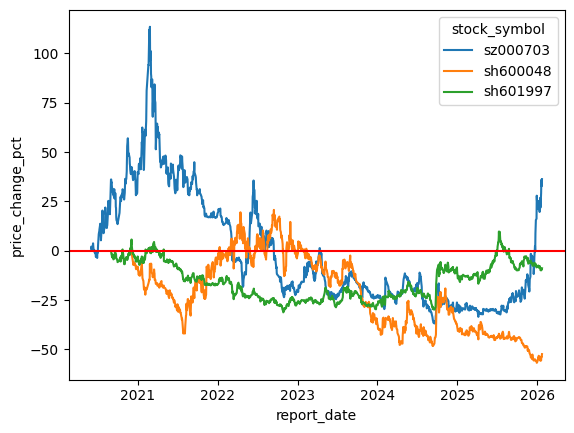

In [187]:
sns.lineplot(stock_check[stock_check['stock_symbol'].isin(bad_perf_stock_codes)], 
             x='report_date', y='price_change_pct', 
             hue='stock_symbol',)
# plot a red horizontal line at 0
plt.axhline(y=0, color='r', linestyle='-')